In [219]:
import numpy as np
import matplotlib.pyplot as plt
import pydicom
import os
import imageio

#%matplotlib qt
#%matplotlib ipympl


In [220]:
root_directory = "HippocampalMRISlices"
patient_num = 1

# Get the list patient folders
patient_folders = sorted(os.listdir(root_directory))

# Get the single patient folder you are looking for 
directory = os.path.join(root_directory, patient_folders[patient_num])

# All the dicoms for a particular folder
dicom_names = os.listdir(directory)


## Viewing a single slice

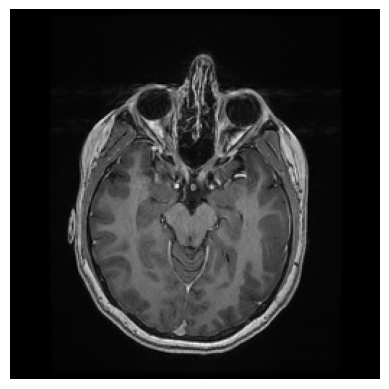

In [221]:
# choose which slice to open using index 
# and find the dicom name for that
# this is directory independent, i.e. will work for other folders too 

# Opening a single dicom 
slice_number = 4

# This find the "name" of the file, and get its full path 
dicom_name = dicom_names[slice_number]
dicom_path = os.path.join(directory, dicom_name)

# read dicom file
ds = pydicom.dcmread(dicom_path)  

# EXTRACTS THE PIXE DATA FROM THE DICOM FILE
image_data = ds.pixel_array 

plt.imshow(image_data, cmap='gray') # print pixel data of dicom file
plt.axis('off')
plt.show()
#print(ds)

## Extracting all dicoms

In [222]:
# Extract all the dicom files in the directory 
dicoms = [] 
for dicom_name in dicom_names:
    dicom_path = os.path.join(directory, dicom_name)
    ds = pydicom.dcmread(dicom_path)
    dicoms.append(ds)

In [201]:
# there are a few different types of dicoms in the directory
# and if you try to load the pixel data for all, 
# the ones without pixel data will fail
# there are a few ways to handle this 

# You can try all the files, and see which fail 
for ind in range(len(dicoms)):
    ds = dicoms[ind]  
    try:
        ds.pixel_array
    except:
        print(f"Failed for file: {dicom_names[ind]}")
        ds_type = ds.file_meta.MediaStorageSOPClassUID.name
        print(f"DS Type: {ds_type}")
        # Remove that value from the list 
        dicoms.pop(ind)
print(f"Total Slices = {len(dicoms)}")

# Or if you know the Class UID Name you are looking for, 
# you can remove unwanted ones from the loaded dicoms
for ind in range(len(dicoms)):
    ds = dicoms[ind]
    ds_type = ds.file_meta.MediaStorageSOPClassUID.name
    if ds_type != 'MR Image Storage':
        dicoms.pop(ind)
print(f"Total Slices = {len(dicoms)}")

# Both these methods should produce the same result


Failed for file: RS.1.2.246.352.221.50225536432001285041133811588211639175.dcm
DS Type: RT Structure Set Storage
Total Slices = 292
Total Slices = 292


In [ ]:
# The order these have been loaded in in not necessarily the 
# correct order so we can extract that here 

# There are a few different dicom attributes that can help us the order 
# ds.ImagePositionPatient
# ds.SliceLocation
# ds.InstanceNumber

# ImagePositionPatient[2] represents the Z-coordinate, 
#   allowing slices to be reconstructed in the correct anatomical order.
# Slice location is the same as ImagePositionPatient[2]
# Instance number is the number of the slice in the series 

# Sorting the list of slices, based on the value in slice order

#dicoms = sorted(dicoms,key=lambda x: float(x.ImagePositionPatient[2]))
dicoms = sorted(dicoms,key=lambda x: float(x.SliceLocation))
#dicoms = sorted(dicoms,key=lambda x: float(x.InstanceNumber))

# Now indexing sequentially will actually get to sequential slices

In [217]:
# extract the pixel arrays, which are now in the correct order 
slices = [ds.pixel_array for ds in dicoms]

# Convert individual 2D array into one 3D NumPy volume
volume = np.stack(slices)

# The resulting array has dimensions: (number of slices, image height, image width)
print(f"Volume dimensions: {volume.shape}")

Volume dimensions: (292, 256, 256)


## Viewing volume data

In [ ]:
# For the get vol data function would be
def get_vol_data_pydicom(patient_num):
    """
    Extract a volume from a dictory with a dicom for each 
    individual slice of the 3D scan
    """    
    # Init the dicoms variable 
    dicoms = [] 

    # Set up the paths to search 
    directory = os.path.join(root_directory, patient_folders[patient_num])
    dicom_names = os.listdir(directory)
    
    # Extract only dicoms of the right type 
    for dicom_name in dicom_names:
        dicom_path = os.path.join(directory, dicom_name)
        ds = pydicom.dcmread(dicom_path)
        
        ds_type = ds.file_meta.MediaStorageSOPClassUID.name
        if ds_type == 'MR Image Storage':
            dicoms.append(ds)
        else:
            print(f"Skipping file: {dicom_names[ind]}")
            print(f"DS Type: {ds_type}")
    
    dicoms = sorted(dicoms,key=lambda ds: float(ds.SliceLocation))
    slices = [ds.pixel_array for ds in dicoms]
    volume = np.stack(slices)

    print(f"Found {len(slices)} slices")
    return (volume)



In [203]:
def get_vol_data(patient_num):  
    """
    function to get data from dicom file
    """
    
    directory = os.path.join(root_directory, patient_folders[patient_num])
    
    # index doesn't seem to do anything here,
    # howver image IO doesn't work with just the folder as input 
    index = 0 
    entry = os.listdir(directory)[index]
    entry_path = os.path.join(directory, entry)
    
    # Vol read here seems to be looking in the entire directory path
    # and loading the data that way, if there was only one file 
    # there this would not extract the whole volume 
    # While this does seem to work, it seems to stuggle to get the 
    # order of the slices correct
    vol_data = imageio.volread(entry_path)  # read dicom file
    
    return vol_data  # return dicom data

def directional_slices(vol, number_of_slice, slice_type):
    '''returns the information of the input vol for 
    the specified slice, to be plotted
    slice_type are defined as 'axial', 'coronal', and 'saggital' 
    number_of_slice defines the specific slice to be returned
    '''

    if slice_type == 'axial':
        return vol[number_of_slice,:,:]
    elif slice_type == 'coronal':
        return vol[:,number_of_slice,:]
    elif slice_type == 'saggital':
        return vol[:,:,number_of_slice]
    else:
        raise ValueError("Please choose from 'axial', 'coronal', or 'saggital', and a slice number must be between 0 and 255")



In [218]:
# View any slice 

directional_slices(volume, 10, 'axial')

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int16)

In [204]:
# Getting the voldata every time is slowing you down, 
# so just do it once 
vol = get_vol_data(3)

Reading DICOM (examining files): 1/333 files (0.3320/333 files (96.1  DICOM file has no SamplesPerPixel (perhaps this is a report?)
Reading DICOM (examining files): 320/333 files (96.1%333/333 files (100.0%)
  Found 1 correct series.
Reading DICOM (loading data): 332/332  (100.0%)


In [205]:
index = 50
axial_slice = directional_slices(vol, index, 'axial')
saggital_slice = directional_slices(vol, index, 'saggital')
coronal_slice = directional_slices(vol, index, 'coronal')

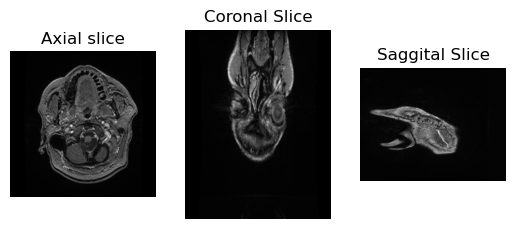

In [206]:
plt.close('all')

#####         AXIAL         #####
plt.subplot(131)
plt.imshow(axial_slice, cmap='gray')
plt.title('Axial slice')
plt.axis('off')

#####    CORONAL    #####
plt.subplot(132)
plt.imshow(coronal_slice, cmap='gray') # print pixel data of dicom file
plt.title('Coronal Slice')
plt.axis('off')

#####    SAGITTAL    #####
plt.subplot(133)
plt.imshow(saggital_slice.T, cmap='gray') # print pixel data of dicom file
plt.title('Saggital Slice')
plt.axis('off')

plt.show()

In [ ]:
# As you have sorted the dicoms above now you don't 
# need the dictionary, but it can br created like: 

dicom_dict = dict(zip(dicom_order, slices))

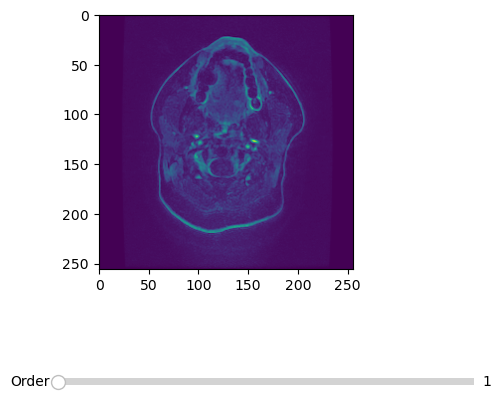

In [ ]:
from matplotlib.widgets import Slider, Button

plt.close('all')
fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.35)
ax_order = plt.axes([0.25, 0.1, 0.65, 0.03])
ax.imshow(dicom_dict[min(dicom_order)])

#create a slider for the dicom files
order_increments = []
for i in range(len(dicom_order)-1):
    increment = dicom_order[i+1]- dicom_order[i]
    order_increments.append(increment)

#print(np.concatenate([np.linspace(0.1,5,100), [6,7,8,9]]))

order_slider = Slider(ax_order, 'Order', min(dicom_order), max(dicom_order), valinit=555011, valstep=order_increments, valfmt='%0.0f', color='lightblue')


def update(val):
    ord = order_slider.val
    ax.imshow(dicom_dict[ord])
    fig.canvas.draw_idle()

order_slider.on_changed(update)

plt.show()


## Rough work from here on

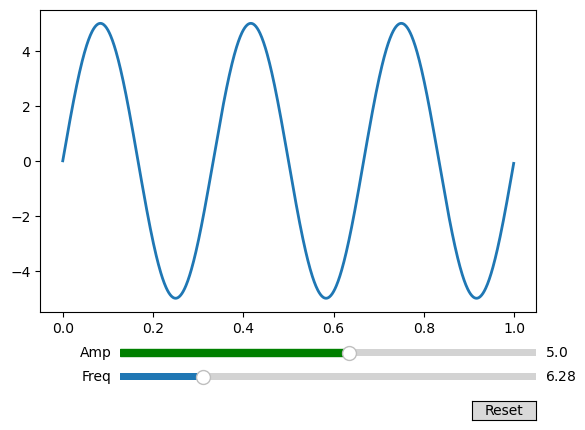

In [14]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.widgets import Button, Slider

t = np.arange(0.0, 1.0, 0.001)
a0 = 5
f0 = 3
s = a0 * np.sin(2 * np.pi * f0 * t)

fig, ax = plt.subplots()
fig.subplots_adjust(bottom=0.25)
l, = ax.plot(t, s, lw=2)

ax_freq = fig.add_axes((0.25, 0.1, 0.65, 0.03))
ax_amp = fig.add_axes((0.25, 0.15, 0.65, 0.03))

# define the values to use for snapping
allowed_amplitudes = np.concatenate([np.linspace(.1, 5, 100), [6, 7, 8, 9]])

# create the sliders
samp = Slider(
    ax_amp, "Amp", 0.1, 9.0,
    valinit=a0, valstep=allowed_amplitudes,
    color="green"
)

sfreq = Slider(
    ax_freq, "Freq", 0, 10*np.pi,
    valinit=2*np.pi, valstep=np.pi,
    initcolor='none'  # Remove the line marking the valinit position.
)


def update(val):
    amp = samp.val
    freq = sfreq.val
    l.set_ydata(amp*np.sin(2*np.pi*freq*t))
    fig.canvas.draw_idle()


sfreq.on_changed(update)
samp.on_changed(update)

ax_reset = fig.add_axes((0.8, 0.025, 0.1, 0.04))
button = Button(ax_reset, 'Reset', hovercolor='0.975')


def reset(event):
    sfreq.reset()
    samp.reset()
button.on_clicked(reset)


plt.show()